# **Open Data II: Machine Learning**- No Supervisado

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dataset_OData_Final_Martin_Otero.csv")

In [2]:
pd.options.display.max_columns = None
df.head()

,FlightDate,sched_dep_dt,sched_arr_dt,dep_dt,arr_dt,Airline,Origin,Dest,DepDelayMinutes,DepDelay,ArrDelayMinutes,TotalDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings,origin_lat,origin_lon,dest_lat,dest_lon,aircraft_age,MODEL,TotalDelayMinutes.1
0,2021-03-03,2021-03-03 07:24:00,2021-03-03 08:43:00,2021-03-03 07:14:00,2021-03-03 08:18:00,SkyWest Airlines Inc.,SGU,PHX,0.0,-10.0,0.0,0.0,49.0,79.0,64.0,262.0,AA,AA_CODESHARE,19805,AA,3133,SkyWest Airlines Inc.,20304,OO,N728SK,3133,14794,1479405,34794,"St. George, UT",UT,49,Utah,87,14107,1410702,30466,"Phoenix, AZ",AZ,4,Arizona,81,0.0,-1.0,0700-0759,10.0,724.0,813.0,5.0,-25.0,0.0,-2.0,0800-0859,2,0.0,37.036389,-113.510306,33.435302,-112.005905,16.0,CL-600-2C10,0.0
1,2021-03-03,2021-03-03 09:22:00,2021-03-03 10:40:00,2021-03-03 09:17:00,2021-03-03 10:31:00,SkyWest Airlines Inc.,PHX,SGU,0.0,-5.0,0.0,0.0,48.0,78.0,74.0,262.0,AA,AA_CODESHARE,19805,AA,3134,SkyWest Airlines Inc.,20304,OO,N752SK,3134,14107,1410702,30466,"Phoenix, AZ",AZ,4,Arizona,81,14794,1479405,34794,"St. George, UT",UT,49,Utah,87,0.0,-1.0,0900-0959,23.0,940.0,1028.0,3.0,-9.0,0.0,-1.0,1000-1059,2,0.0,33.435302,-112.005905,37.036389,-113.510306,16.0,CL-600-2C10,0.0
2,2021-03-03,2021-03-03 13:30:00,2021-03-03 15:30:00,2021-03-03 13:21:00,2021-03-03 15:01:00,SkyWest Airlines Inc.,MHT,ORD,0.0,-9.0,0.0,0.0,129.0,180.0,160.0,843.0,AA,AA_CODESHARE,19805,AA,3135,SkyWest Airlines Inc.,20304,OO,N766SK,3135,13296,1329604,30721,"Manchester, NH",NH,33,New Hampshire,14,13930,1393007,30977,"Chicago, IL",IL,17,Illinois,41,0.0,-1.0,1300-1359,15.0,1336.0,1445.0,16.0,-29.0,0.0,-2.0,1500-1559,4,0.0,42.932598,-71.435699,41.978600,-87.904800,16.0,CL-600-2C10,0.0
3,2021-03-03,2021-03-03 16:45:00,2021-03-03 20:10:00,2021-03-03 16:36:00,2021-03-03 20:02:00,SkyWest Airlines Inc.,DFW,TRI,0.0,-9.0,0.0,0.0,112.0,145.0,146.0,868.0,AA,AA_CODESHARE,19805,AA,3136,SkyWest Airlines Inc.,20304,OO,N752EV,3136,11298,1129806,30194,"Dallas/Fort Worth, TX",TX,48,Texas,74,15323,1532305,35323,"Bristol/Johnson City/Kingsport, TN",TN,47,Tennessee,54,0.0,-1.0,1600-1659,27.0,1703.0,1955.0,7.0,-8.0,0.0,-1.0,2000-2059,4,0.0,32.896801,-97.038002,36.475201,-82.407401,NaN,CL-600-2C10,0.0
4,2021-03-03,2021-03-03 18:44:00,2021-03-03 19:25:00,2021-03-03 18:38:00,2021-03-03 19:03:00,SkyWest Airlines Inc.,PHX,BFL,0.0,-6.0,0.0,0.0,69.0,101.0,85.0,425.0,AA,AA_CODESHARE,19805,AA,3137,SkyWest Airlines Inc.,20304,OO,N715SK,3137,14107,1410702,30466,"Phoenix, AZ",AZ,4,Arizona,81,10561,1056103,30561,"Bakersfield, CA",CA,6,California,91,0.0,-1.0,1800-1859,13.0,1851.0,1900.0,3.0,-22.0,0.0,-2.0,1900-1959,2,0.0,33.435302,-112.005905,35.433601,-119.056999,17.0,CL-600-2C10,0.0


In [3]:
print(df["Origin"].nunique())

print(df["Origin"].value_counts().describe())

vc = df["Origin"].value_counts()
print(( vc > 100 ).sum())
print(( vc > 200 ).sum())

372
count       372.000000
mean      16418.099462
std       40093.513282
min          28.000000
25%         741.500000
50%        2842.000000
75%       11182.000000
max      307966.000000
Name: count, dtype: float64
364
358


In [4]:
# 2. Target Encoding para la variable categórica 'Airline'
airline_target_dict = df.groupby('Airline')['TotalDelayMinutes'].mean().to_dict()

# Mapeo este valor al dataset: convierte el nombre ('Delta') en un número (ej. 15.2 min)
df['airline_target_enc'] = df['Airline'].map(airline_target_dict)

# 3. Creación de variables temporales
# Extraigo la hora para identificar vuelos en franjas propensas al "efecto bola de nieve"
df['hour'] = pd.to_datetime(df['sched_dep_dt']).dt.hour
df['is_late_night'] = (df['hour'] >= 18).astype(int)

print("Ingeniería de características base completada.")

Ingeniería de características base completada.


## **1. Clustering de Aeropuertos** (Origen) por comportamiento

He comprimido los millones de registros en perfiles únicos por aeropuerto. He incluido variables de volumen, medias de tiempos (vuelo, pistas, retrasos), la calidad de las aerolíneas que operan allí (Target Encoding) y medidas de desviación estándar (`std`) para evaluar la **predictibilidad** o inestabilidad del aeropuerto.

He aplicado un filtro mínimo de 100 vuelos históricos para garantizar que los promedios calculados tengan robustez estadística y no estén sesgados por aeropuertos con actividad marginal. *(Nota: En una fase posterior contrastaré este modelo incluyendo toda la red de aeropuertos locales).*

In [ ]:
# Agrupación por aeropuerto para crear la matriz de características (Feature Matrix)
airport_profiles = df.groupby('Origin').agg(
    # Métricas de Retraso y Predictibilidad
    avg_delay=('TotalDelayMinutes', 'mean'),
    std_delay=('TotalDelayMinutes', 'std'),
    
    # Métricas Operativas en Pista
    avg_taxi_out=('TaxiOut', 'mean'),
    std_taxi_out=('TaxiOut', 'std'),
    avg_taxi_in=('TaxiIn', 'mean'),
    
    # Métricas de Vuelo y Flota
    avg_distance=('Distance', 'mean'),
    avg_airtime=('AirTime', 'mean'),
    avg_age=('aircraft_age', 'mean'),
    
    # Nuevas Variables (Target Encoding y Temporales)
    avg_airline_quality=('airline_target_enc', 'mean'), # ¿Operan buenas aerolíneas aquí?
    late_night_ratio=('is_late_night', 'mean'),         # % de vuelos nocturnos
    
    # Metadatos para contexto y mapas
    flight_volume=('TotalDelayMinutes', 'count'),
    lat=('origin_lat', 'first'),
    lon=('origin_lon', 'first')
).reset_index()

airport_ml = airport_profiles.dropna().query('flight_volume > 500').copy()

print(f"Perfiles creados. Analizando {len(airport_ml)} aeropuertos representativos.")

Perfiles creados. Analizando 342 aeropuertos representativos.



--- TABLA DE VARIANZA EXPLICADA (PCA) ---
 Componente  Varianza_Ind_ %  Varianza_Acum_ %
          1        35.272625         35.272625
          2        24.552011         59.824635
          3        13.926070         73.750705
          4         8.183345         81.934051
          5         7.209891         89.143941
          6         4.397886         93.541827
          7         3.619233         97.161060
          8         1.486662         98.647722
          9         1.283505         99.931227
         10         0.068773        100.000000


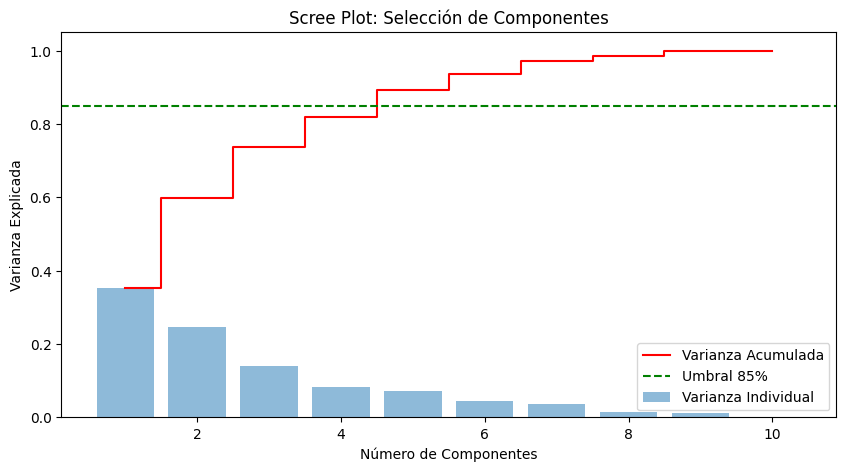

5


In [6]:
features = [c for c in airport_ml.columns if c not in ['Origin', 'lat', 'lon', 'flight_volume']]
X = StandardScaler().fit_transform(airport_ml[features])

pca_full = PCA()
pca_full.fit(X)
exp_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

# Tabla de Varianza
print("\n--- TABLA DE VARIANZA EXPLICADA (PCA) ---")
df_pca_table = pd.DataFrame({
    'Componente': range(1, len(exp_var) + 1),
    'Varianza_Ind_ %': exp_var * 100,
    'Varianza_Acum_ %': cum_var * 100
})
print(df_pca_table.to_string(index=False))

# Gráfico Scree Plot
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.5, label='Varianza Individual')
plt.step(range(1, len(cum_var) + 1), cum_var, where='mid', label='Varianza Acumulada', color='red')
plt.axhline(y=0.85, color='g', linestyle='--', label='Umbral 85%')
plt.title('Scree Plot: Selección de Componentes')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada')
plt.legend()
plt.show()

n_optimo = np.argmax(cum_var >= 0.85) + 1
print(n_optimo)
X_pca = PCA(n_components=n_optimo).fit_transform(X)

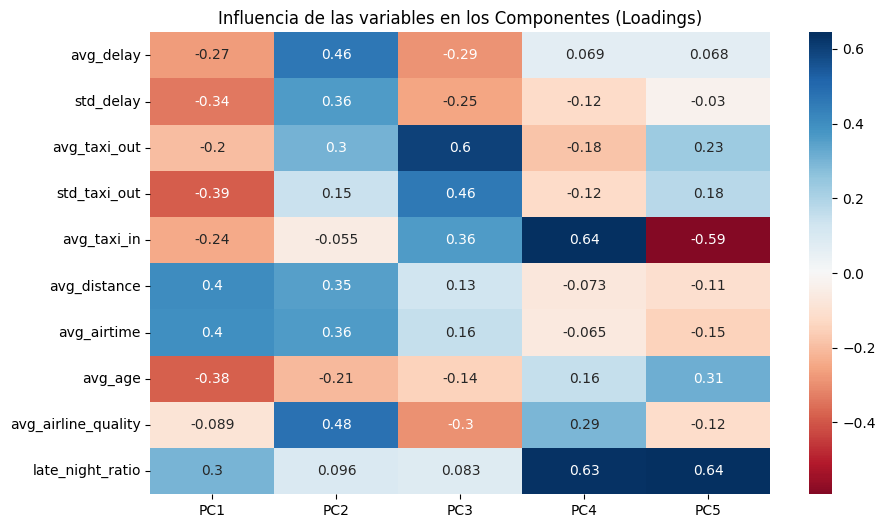

In [7]:
# --- NUEVO: Mapa de calor para interpretar qué significa cada PCA ---
loadings = pd.DataFrame(
    pca_full.components_.T, 
    columns=[f'PC{i+1}' for i in range(len(features))], 
    index=features
)

plt.figure(figsize=(10, 6))
sns.heatmap(loadings.iloc[:, :n_optimo], annot=True, cmap='RdBu', center=0)
plt.title('Influencia de las variables en los Componentes (Loadings)')
plt.show()

- PC1 (Congestion y Retraso): Es el componente mas fuerte. Mide la ineficiencia operativa. Valores altos indican aeropuertos con promedios de retraso elevados (avg_delay) y mucha variabilidad (std_delay), sumado a tiempos largos de salida a pista (taxi_out).

- PC2 (Perfil de Vuelo/Distancia): Define si el aeropuerto es de largo alcance. Esta dominado por avg_distance y avg_airtime. Un valor alto aqui indica aeropuertos que gestionan vuelos transcontinentales o internacionales.

- PC3 (Operacion en Tierra): Se centra especificamente en la eficiencia de llegada. Valores altos reflejan tiempos de rodaje de llegada (avg_taxi_in) prolongados, independientemente de si el vuelo viene retrasado o no.

- PC4 (Antiguedad y Calidad de Flota): Relaciona la edad promedio de los aviones (avg_age) y la calidad de las aerolineas (airline_target_enc). Ayuda a diferenciar aeropuertos que sirven de base para flotas mas modernas frente a los de flotas mas antiguas.

- PC5 (Actividad Nocturna): Representa la proporcion de vuelos nocturnos (late_night_ratio). Identifica aeropuertos que operan en horarios menos convencionales o que tienen hubs de carga/redistribucion nocturna.


--- TABLA DE VALIDACIÓN DE CLÚSTERES (K) ---
 K  Inercia (Codo)  Silhouette Score
 2     2207.458288          0.262593
 3     1762.579578          0.264205
 4     1506.692240          0.272052
 5     1346.130975          0.233518
 6     1216.602894          0.251625
 7     1107.325695          0.254403
 8     1009.556256          0.258845
 9      939.723484          0.227445
10      882.730577          0.234949


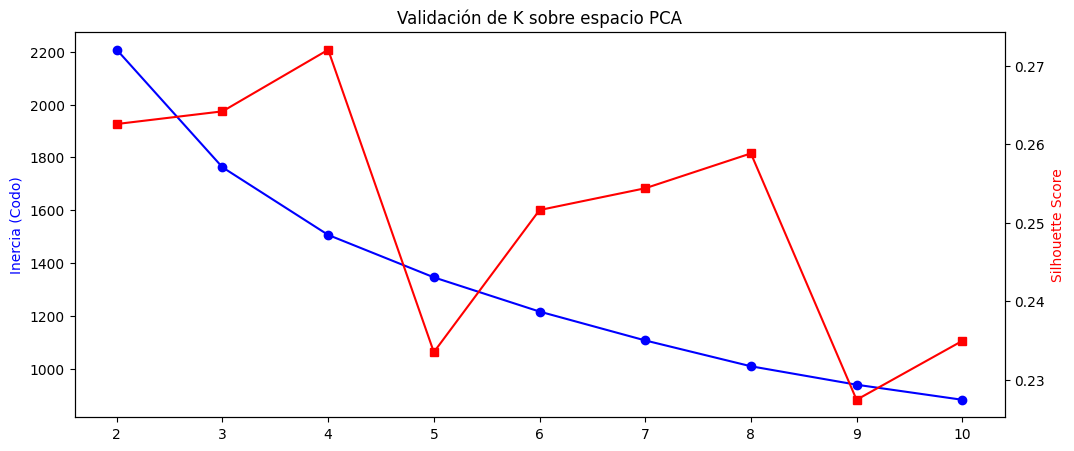

In [8]:
range_n = range(2, 11)
inertias = []
silhouettes = []

for n in range_n:
    km = KMeans(n_clusters=n, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

# Tabla de Métricas de K
print("\n--- TABLA DE VALIDACIÓN DE CLÚSTERES (K) ---")
df_k_table = pd.DataFrame({
    'K': range_n,
    'Inercia (Codo)': inertias,
    'Silhouette Score': silhouettes
})
print(df_k_table.to_string(index=False))

# Gráfico Dual Elbow/Silhouette
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(range_n, inertias, 'bo-', label='Inercia')
ax1.set_ylabel('Inercia (Codo)', color='blue')
ax2 = ax1.twinx()
ax2.plot(range_n, silhouettes, 'rs-', label='Silhouette')
ax2.set_ylabel('Silhouette Score', color='red')
plt.title('Validación de K sobre espacio PCA')
plt.show()

In [9]:
# Primero definimos el modelo con el K que elegimos
k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)

# AQUÍ se crea la columna 'Cluster' en tu dataframe airport_ml
airport_ml['Cluster'] = kmeans.fit_predict(X_pca).astype(str)

In [10]:
# --- Gráfica de dispersión PCA (Corregida sin errores de estilo) ---
# --- Grafica de dispersion PCA con Labels Reales ---
fig_pca = px.scatter(
    X_pca, 
    x=0, 
    y=1, 
    color=airport_ml['Cluster'],
    # Labels basados en la interpretacion de los loadings
    labels={
        '0': 'PC1: Congestion y Retraso (Ineficiencia)', 
        '1': 'PC2: Perfil de Vuelo (Larga Distancia)'
    },
    title="Analisis PCA: Segmentacion por Ineficiencia vs Distancia de Vuelo",
    hover_name=airport_ml['Origin'],
    template='plotly_white',
    color_discrete_sequence=px.colors.qualitative.D3
)

fig_pca.update_traces(marker=dict(size=8, opacity=0.7, line=dict(width=1, color='DarkSlateGrey')))
fig_pca.show()

# 2. Tu Mapa Final con fondo blanco
fig_map = px.scatter_geo(
    airport_ml, lat='lat', lon='lon', color='Cluster',
    hover_name='Origin', size='flight_volume',
    scope='usa', title=f"Mapa Final: Clústeres (K={k_final} sobre PCA {n_optimo}D)",
    template='plotly_white', 
    color_discrete_sequence=px.colors.qualitative.D3
)
fig_map.update_traces(marker=dict(opacity=0.8, line=dict(width=1, color='black')))
fig_map.show()

In [11]:
# --- Tabla de Caracterizacion de Clusters ---
# Seleccionamos las columnas clave para comparar
cols_analisis = [
    'avg_delay', 'avg_taxi_out', 'avg_taxi_in', 
    'avg_distance', 'avg_age', 'late_night_ratio', 'flight_volume'
]

tabla_clusters = airport_ml.groupby('Cluster')[cols_analisis].mean().sort_values(by='avg_delay')

print("\n--- CARACTERIZACION DE LOS CLUSTERS (PROMEDIOS) ---")
print(tabla_clusters.round(2).to_string())

# Tip para el reporte:
# Cluster con avg_delay mas bajo = "Los Eficientes"
# Cluster con avg_distance mas alto = "Hubs de Larga Distancia"
# Cluster con avg_taxi_out mas alto = "Congestionados en Pista"


--- CARACTERIZACION DE LOS CLUSTERS (PROMEDIOS) ---
         avg_delay  avg_taxi_out  avg_taxi_in  avg_distance  avg_age  late_night_ratio  flight_volume
Cluster                                                                                              
0            19.66         10.90         6.67        253.45    17.26              0.10        1165.50
2            24.87         15.18        11.19        351.76    15.61              0.11        4346.98
3            26.40         14.30         8.08        761.68    10.74              0.17       42917.19
1            41.95         16.23         9.17        387.74    16.64              0.05        1789.41


# **2. Clustering**- de Perfiles de Flota por Aerolínea y Familia
Este modelo agrupa combinaciones de aerolínea y familia de aviones para identificar patrones de eficiencia y comportamiento operativo.

- Preparación: He consolidado métricas por Aerolínea y Familia, rescatando operadoras clave mediante imputación de datos.
- PCA: He reducido las variables a los 3 componentes principales óptimos para capturar la máxima varianza con menor ruido.
- Validación: He determinado el uso de 4 grupos tras analizar las métricas de Inercia y Silhouette.
- Grafica 1: Heatmap categórico para visualizar el nivel de impacto operativo según la flota de cada compañía.
- Fuzzy: He aplicado Logica Difusa para calcular la probabilidad de pertenencia de cada flota a sus respectivos clústeres.

In [12]:
def model_family(model_name):
    """
    Función para agrupar modelos específicos en familias (ej. B737-800 -> B737)
    """
    model_name = str(model_name).upper()
    if 'B737' in model_name: return 'B737'
    elif 'B777' in model_name: return 'B777'
    elif 'B787' in model_name: return 'B787'
    elif 'A320' in model_name or 'A321' in model_name: return 'A320 Family'
    elif 'A330' in model_name: return 'A330'
    elif 'A350' in model_name: return 'A350'
    elif 'CRJ' in model_name: return 'CRJ'
    elif 'ERJ' in model_name or 'E1' in model_name: return 'ERJ'
    elif 'MD' in model_name: return 'MD'
    else: return 'Other'


--- TABLA DE VARIANZA ACUMULADA ---


,Varianza Individual,Varianza Acumulada
PC1,41.67%,41.67%
PC2,23.47%,65.14%
PC3,14.84%,79.98%
PC4,9.52%,89.50%
PC5,4.92%,94.42%
PC6,3.77%,98.19%
PC7,1.81%,100.00%



--- MATRIZ DE COMPOSICIÓN (LOADINGS) ---


,PC1,PC2
avg_delay,0.454,0.412
std_delay,0.501,0.154
avg_taxi_out,0.428,-0.356
avg_taxi_in,0.434,-0.334
avg_distance,0.292,-0.429
avg_airline_quality,0.278,0.610
late_night_ratio,0.096,-0.115


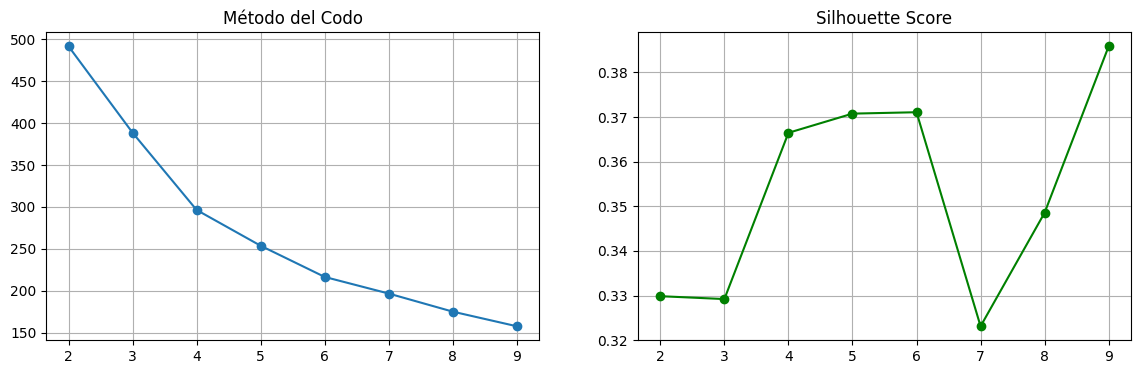


--- MUESTRA DE PERTENENCIA FUZZY POR CLÚSTER ---


,Airline,MODEL,Cluster,Conf_Cluster_0,Conf_Cluster_1,Conf_Cluster_2,Conf_Cluster_3
0,Air Wisconsin Airlines Corp,CL-600-2B19,3,0.886620,0.043383,0.033307,0.036690
1,Alaska Airlines Inc.,737-790,2,0.112011,0.084123,0.499265,0.304602
2,Alaska Airlines Inc.,737-890,0,0.064990,0.116698,0.083329,0.734983
3,Alaska Airlines Inc.,737-8FH,0,0.081706,0.133727,0.149666,0.634901
4,Alaska Airlines Inc.,737-9,0,0.125506,0.287118,0.104365,0.483011
5,Alaska Airlines Inc.,737-900ER,0,0.072939,0.137091,0.097163,0.692807
6,Alaska Airlines Inc.,737-990ER,0,0.062805,0.116678,0.079651,0.740867
7,Alaska Airlines Inc.,A320-214,0,0.026450,0.041500,0.028183,0.903867
8,Allegiant Air,A319-111,3,0.477840,0.138157,0.249946,0.134058
9,Allegiant Air,A319-112,3,0.498959,0.153784,0.215574,0.131683


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import skfuzzy as fuzz
import plotly.express as px

# --- 1. PREPARACIÓN (Sin dropna agresivo para no perder a Southwest) ---
# Nos aseguramos de que Southwest no se pierda por nombres o nulos puntuales
df['Airline'] = df['Airline'].astype(str).str.strip()

fleet_profiles = df.groupby(['Airline', 'MODEL']).agg(
    avg_delay=('TotalDelayMinutes', 'mean'),
    std_delay=('TotalDelayMinutes', 'std'),
    avg_taxi_out=('TaxiOut', 'mean'),
    avg_taxi_in=('TaxiIn', 'mean'),
    avg_distance=('Distance', 'mean'),
    avg_airline_quality=('airline_target_enc', 'mean'),
    late_night_ratio=('is_late_night', 'mean'),
    flight_volume=('TotalDelayMinutes', 'count')
).reset_index()

# En lugar de dropna(), imputamos la mediana en las métricas para salvar filas
features = ['avg_delay', 'std_delay', 'avg_taxi_out', 'avg_taxi_in', 'avg_distance', 'avg_airline_quality', 'late_night_ratio']
for col in features:
    fleet_profiles[col] = fleet_profiles[col].fillna(fleet_profiles[col].median())

# Filtro de volumen (bajado a 50 para máxima cobertura)
fleet_ml = fleet_profiles[fleet_profiles['flight_volume'] > 500].copy()
fleet_ml['Family'] = fleet_ml['MODEL'].apply(model_family)

# --- 2. PCA: TABLA DE VARIANZA ACUMULADA (LO PRIMERO) ---
X_scaled = StandardScaler().fit_transform(fleet_ml[features])
pca_full = PCA().fit(X_scaled)

var_exp = pca_full.explained_variance_ratio_
cum_var = np.cumsum(var_exp)

print("--- TABLA DE VARIANZA ACUMULADA ---")
df_var = pd.DataFrame({
    'Varianza Individual': [f"{v*100:.2f}%" for v in var_exp],
    'Varianza Acumulada': [f"{c*100:.2f}%" for c in cum_var]
}, index=[f'PC{i+1}' for i in range(len(var_exp))])
display(df_var)

# --- 3. EXPLICACIÓN DE EJES (LOADINGS) ---
# Los Loadings indican cuánto pesa cada variable en cada componente
loadings = pd.DataFrame(
    pca_full.components_.T, 
    columns=[f'PC{i+1}' for i in range(len(features))], 
    index=features
)
print("\n--- MATRIZ DE COMPOSICIÓN (LOADINGS) ---")
display(loadings[['PC1', 'PC2']].round(3))

# Nombramos los ejes según la variable con mayor peso absoluto
eje_x_name = f"PC1: Eficiencia ({loadings['PC1'].abs().idxmax()})"
eje_y_name = f"PC2: Dimensión Ruta ({loadings['PC2'].abs().idxmax()})"

# --- 4. VALIDACIÓN (ELBOW & SILHOUETTE) ---
X_pca = PCA(n_components=3).fit_transform(X_scaled)
k_range = range(2, 10)
inertia = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_pca).inertia_ for k in k_range]
sil = [silhouette_score(X_pca, KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_pca).labels_) for k in k_range]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(k_range, inertia, 'o-'); ax1.set_title('Método del Codo'); ax1.grid(True)
ax2.plot(k_range, sil, 'o-', color='green'); ax2.set_title('Silhouette Score'); ax2.grid(True)
plt.show()

# --- 5. CLUSTERING Y HEATMAP ---

k_opt = 4
km = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
fleet_ml['Cluster'] = km.fit_predict(X_pca)

# Creamos la matriz
heatmap_data = fleet_ml.pivot_table(index='Airline', columns='Family', values='Cluster', aggfunc='first')

eda_colors = ['#2ca02c', '#ff7f0e', '#d62728', '#9467bd'] # O usa px.colors.diverging.RdYlGn[::-1]
custom_eda_palette = [
    [0.0, '#1a9850'], [0.25, '#1a9850'],  # Verde (Eficiente)
    [0.25, '#fee08b'], [0.5, '#fee08b'],   # Amarillo (Aviso)
    [0.5, '#f46d43'], [0.75, '#f46d43'],   # Naranja (Preocupante)
    [0.75, '#d73027'], [1.0, '#d73027']    # Rojo (Crítico)
]
fig_heat = px.imshow(
    heatmap_data, 
    color_continuous_scale=custom_eda_palette, 
    title="Heatmap: Segmentación Estratégica de Flota (Lógica de Rendimiento)", 
    aspect="auto",
    labels=dict(x="Familia de Avión", y="Aerolínea", color="Nivel")
)
fig_heat.update_layout(
    coloraxis_colorbar=dict(
        title="Impacto",
        tickmode='array',
        tickvals=[0.375, 1.125, 1.875, 2.625],
        ticktext=["Óptimo", "Regular", "Degradado", "Crítico"],
        lenmode="pixels", len=300
    )
)
fig_heat.show()

# --- 6. DISPERSIÓN CON EJES EXPLICADOS ---
fig_scatter = px.scatter(
    fleet_ml, x=X_pca[:, 0], y=X_pca[:, 1],
    color=fleet_ml['Cluster'].astype(str), symbol='Family',
    labels={'x': eje_x_name, 'y': eje_y_name},
    title="Análisis de Flotas en Espacio PCA ",
    hover_data=['Airline', 'MODEL'], template='plotly_white'
)
fig_scatter.show()

# --- 7. FUZZY LOGIC: CONFIANZA POR CLÚSTER ---
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(X_pca.T, c=k_opt, m=2, error=0.005, maxiter=1000)

# Añadimos la probabilidad de pertenencia a CADA clúster
for i in range(k_opt):
    fleet_ml[f'Conf_Cluster_{i}'] = u[i]

print("\n--- MUESTRA DE PERTENENCIA FUZZY POR CLÚSTER ---")
display(fleet_ml[['Airline', 'MODEL', 'Cluster'] + [f'Conf_Cluster_{i}' for i in range(k_opt)]].head(10))

# **Clustering 3**: DBSCAN- Diagnostico de Anomalias en Rutas Aereas

- Mismo paso que en los anteriores: Perfilado por terminal y tramo: Agrupo los datos por origen y destino para evaluar el rendimiento de cada terminal. Calculo promedios de retraso, tiempos de rodaje (taxi-in/out) y distancia para identificar cuellos de botella operativos.

- Calculo de Epsilon: Utilizo la grafica de distancias al vecino mas cercano (metodo del codo). El valor de Epsilon (0.6) se elige en el punto donde la curva sube bruscamente.

- Visualizacion de Clusters: En la grafica de dispersion, comparo la distancia frente al retraso promedio. Los puntos naranjas (Cluster 0) son la operacion estable, mientras que los puntos negros (Cluster -1) representan las rutas que el modelo aisla por su comportamiento ineficiente.

- Top 10 de rutas criticas: Genero un listado de las 10 rutas con mayor desviacion. Este ranking permite priorizar que conexiones requieren intervencion inmediata por presentar los mayores retrasos acumulados.

- Mapa interactivo por aerolinea: Es la herramienta mas importante de mi estudio. Agrupo por Origen, Destino y Aerolinea para ver como opera cada compania. Las lineas rojas resaltan las anomalias con sus codigos IATA (ej. JFK, ORD), permitiendo diferenciar visualmente si el problema es del aeropuerto o de la propia aerolinea.

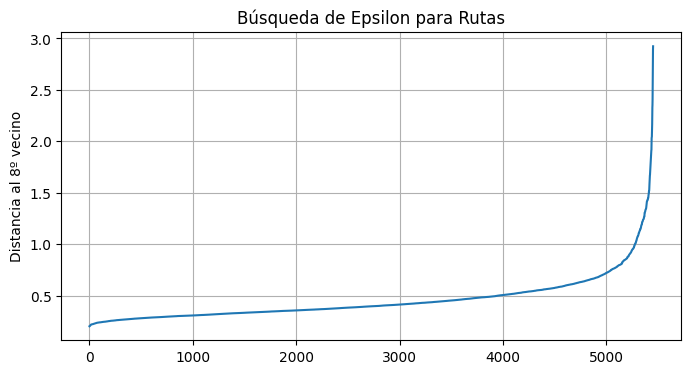

--- TOP 10 RUTAS ANÓMALAS O CRÍTICAS (CLUSTER -1) ---


,Origin,Dest,avg_delay,avg_taxi_out,avg_taxi_in,distance
4576,OGG,SLC,110.013043,13.995652,6.334783,2935.0
5653,RNO,JFK,104.875000,12.388889,14.402778,2411.0
1638,DEN,DIK,101.486538,19.467308,5.286538,488.0
6244,SGU,DFW,100.835681,17.586854,11.751174,976.0
3338,LAS,BDL,93.508197,14.158470,8.032787,2297.0
2260,EWR,PQI,90.273529,25.376471,5.652941,515.0
6900,WYS,DEN,89.034483,14.943966,9.797414,469.0
3511,LAX,JAX,88.470588,16.723529,5.494118,2153.0
2149,EGE,MIA,87.568807,16.385321,8.403670,1810.0
94,ALB,PIE,86.313043,14.921739,6.826087,1138.0


In [14]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# --- 1. PERFILADO DE RUTAS ---
# Agrupamos por Origen y Destino para evaluar el tramo
route_profiles = df.groupby(['Origin', 'Dest']).agg(
    avg_delay=('TotalDelayMinutes', 'mean'),
    avg_taxi_out=('TaxiOut', 'mean'),
    avg_taxi_in=('TaxiIn', 'mean'),
    distance=('Distance', 'mean'),
    flight_volume=('TotalDelayMinutes', 'count')
).reset_index()

# Filtramos rutas con muy pocos vuelos para evitar ruido estadístico (mínimo 100 vuelos)
route_ml = route_profiles[route_profiles['flight_volume'] > 100].copy()

# --- 2. PREPARACIÓN Y ESCALADO ---
route_features = ['avg_delay', 'avg_taxi_out', 'avg_taxi_in', 'distance']

# Rellenamos posibles nulos con la mediana para no perder rutas
for col in route_features:
    route_ml[col] = route_ml[col].fillna(route_ml[col].median())

X_route_scaled = StandardScaler().fit_transform(route_ml[route_features])

# --- 3. ESTIMACIÓN DE EPSILON (Codo) ---
# Usamos el doble de dimensiones para los vecinos (4 variables * 2 = 8)
neighbors_route = NearestNeighbors(n_neighbors=8)
neighbors_route_fit = neighbors_route.fit(X_route_scaled)
distances_route, _ = neighbors_route_fit.kneighbors(X_route_scaled)
distances_route = np.sort(distances_route[:, 7], axis=0)

plt.figure(figsize=(8, 4))
plt.plot(distances_route)
plt.title('Búsqueda de Epsilon para Rutas')
plt.ylabel('Distancia al 8º vecino')
plt.grid(True)
plt.show()

# --- 4. EJECUCIÓN DE DBSCAN ---
# eps=0.6 es un valor estándar de partida con datos escalados, ajusta según veas la gráfica del codo
dbscan_routes = DBSCAN(eps=0.6, min_samples=8)
route_ml['Route_Cluster'] = dbscan_routes.fit_predict(X_route_scaled)

# --- 5. VISUALIZACIÓN INTERACTIVA ---
fig_routes = px.scatter(
    route_ml, 
    x='distance', 
    y='avg_delay',
    color=route_ml['Route_Cluster'].astype(str),
    hover_data=['Origin', 'Dest', 'avg_taxi_out', 'avg_taxi_in'],
    title="Agrupación de Rutas: Distancia vs Retraso (Puntos negros = Anomalías)",
    labels={'distance': 'Distancia del Vuelo', 'avg_delay': 'Retraso Promedio (min)'},
    color_discrete_map={'-1': 'black'}, # Resaltamos las rutas críticas en negro
    template='plotly_white'
)
fig_routes.show()

# --- 6. IDENTIFICACIÓN DE ZONAS CALIENTES ---
print("--- TOP 10 RUTAS ANÓMALAS O CRÍTICAS (CLUSTER -1) ---")
outlier_routes = route_ml[route_ml['Route_Cluster'] == -1].sort_values(by='avg_delay', ascending=False)
display(outlier_routes[['Origin', 'Dest', 'avg_delay', 'avg_taxi_out', 'avg_taxi_in', 'distance']].head(10))

In [21]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# --- 1. PREPARACIÓN DE DATOS (Granularidad por Aerolínea) ---
route_ml_map = df.groupby(['Origin', 'Dest', 'Airline']).agg(
    avg_delay=('TotalDelayMinutes', 'mean'),
    avg_taxi_out=('TaxiOut', 'mean'),
    avg_taxi_in=('TaxiIn', 'mean'),
    distance=('Distance', 'mean'),
    lat_o=('origin_lat', 'first'),
    lon_o=('origin_lon', 'first'),
    lat_d=('dest_lat', 'first'),
    lon_d=('dest_lon', 'first'),
    volumen=('TotalDelayMinutes', 'count')
).reset_index()

route_ml_map = route_ml_map[route_ml_map['volumen'] > 100].copy()
route_ml_map = route_ml_map.dropna(subset=['lat_o', 'lon_o', 'lat_d', 'lon_d'])

# --- 2. CLUSTERING ---
features = ['avg_delay', 'avg_taxi_out', 'avg_taxi_in', 'distance']
X_scaled = StandardScaler().fit_transform(route_ml_map[features])
db = DBSCAN(eps=0.6, min_samples=8)
route_ml_map['Route_Cluster'] = db.fit_predict(X_scaled)

# --- 3. CONSTRUCCIÓN DEL MAPA ---
fig = go.Figure()
airlines = sorted(route_ml_map['Airline'].unique())

for airline in airlines:
    df_air = route_ml_map[route_ml_map['Airline'] == airline]
    norm = df_air[df_air['Route_Cluster'] != -1]
    anom = df_air[df_air['Route_Cluster'] == -1]
    
    if len(norm) > 150: norm = norm.sample(150, random_state=42)
    
    # A. RUTAS NORMALES (Gris tenue, sin etiquetas)
    lons_n, lats_n, text_n = [], [], []
    for _, r in norm.iterrows():
        lons_n.extend([r['lon_o'], r['lon_d'], None])
        lats_n.extend([r['lat_o'], r['lat_d'], None])
        info = f"{r['Origin']} ➔ {r['Dest']} (Normal)"
        text_n.extend([info, info, info])
        
    fig.add_trace(go.Scattergeo(
        locationmode='USA-states', lon=lons_n, lat=lats_n,
        mode='lines', line=dict(width=0.5, color='lightgray'),
        opacity=0.3, name=f"Normal {airline}",
        legendgroup=airline, visible=(airline == airlines[0]),
        hoverinfo='text', text=text_n
    ))

    # B. RUTAS ANÓMALAS (Rojo, con códigos IATA en los extremos)
    for _, r in anom.iterrows():
        fig.add_trace(go.Scattergeo(
            locationmode='USA-states',
            lon=[r['lon_o'], r['lon_d']],
            lat=[r['lat_o'], r['lat_d']],
            mode='lines+markers+text', # <--- Texto activado
            line=dict(width=2.5, color='red'),
            marker=dict(size=4, color='darkred'),
            text=[r['Origin'], r['Dest']], # <--- Etiquetas IATA
            textposition="top center",
            textfont=dict(size=9, color="black", family="Arial Black"),
            name=f"ANOMALÍA {airline}",
            legendgroup=airline,
            visible=(airline == airlines[0]),
            hoverinfo='text',
            hovertext=f"<b>Ruta CRÍTICA</b><br>{r['Origin']} ➔ {r['Dest']}<br>Retraso: {r['avg_delay']:.1f} min"
        ))

# --- 4. LAYOUT PROFESIONAL (Sin choques) ---
buttons = []
for i, airline in enumerate(airlines):
    visible_mask = [False] * len(fig.data)
    for j, trace in enumerate(fig.data):
        if trace.legendgroup == airline: visible_mask[j] = True
    buttons.append(dict(label=airline, method="update", args=[{"visible": visible_mask}]))

fig.update_layout(
    title={
        'text': "<b>Diagnóstico Geográfico de Anomalías</b><br><span style='font-size:12px'>Códigos IATA resaltados solo en rutas críticas</span>",
        'y': 0.96, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'
    },
    updatemenus=[dict(
        active=0, buttons=buttons, 
        x=0.02, y=0.92, # Espacio suficiente para no chocar
        xanchor='left', yanchor='top',
        bgcolor='white', bordercolor='gray'
    )],
    geo=dict(scope='usa', showland=True, landcolor="white", subunitcolor="lightgrey"),
    margin={"r": 0, "t": 130, "l": 0, "b": 0}, # Margen superior amplio
    height=750,
    showlegend=False,
    template='plotly_white'
)

fig.show()